In [97]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import requests

In [98]:
# Basic OpenF1 API interaction to get season results
BASE_URL = "https://api.openf1.org/v1"
def get_season_results(season: int) -> pd.DataFrame:
    url = f"{BASE_URL}/sessions"
    params = {
        "year": season
        }
    sessions = requests.get(url, params=params)
    sessions.raise_for_status()
    session_data = sessions.json()
    return pd.DataFrame(session_data)

In [99]:
# Example usage
df = get_season_results(2023)
df.head()

,session_key,session_type,session_name,date_start,date_end,meeting_key,circuit_key,circuit_short_name,country_key,country_code,country_name,location,gmt_offset,year
0,9222,Practice,Day 1,2023-02-23T07:00:00+00:00,2023-02-23T16:30:00+00:00,1140,63,Sakhir,36,BRN,Bahrain,Sakhir,03:00:00,2023
1,7763,Practice,Day 2,2023-02-24T07:00:00+00:00,2023-02-24T16:30:00+00:00,1140,63,Sakhir,36,BRN,Bahrain,Sakhir,03:00:00,2023
2,7764,Practice,Day 3,2023-02-25T07:00:00+00:00,2023-02-25T16:30:00+00:00,1140,63,Sakhir,36,BRN,Bahrain,Sakhir,03:00:00,2023
3,7765,Practice,Practice 1,2023-03-03T11:30:00+00:00,2023-03-03T12:30:00+00:00,1141,63,Sakhir,36,BRN,Bahrain,Sakhir,03:00:00,2023
4,7766,Practice,Practice 2,2023-03-03T15:00:00+00:00,2023-03-03T16:00:00+00:00,1141,63,Sakhir,36,BRN,Bahrain,Sakhir,03:00:00,2023


In [100]:
# Get session results
def get_session_results(session_id: int) -> pd.DataFrame:
    url = f"{BASE_URL}/session_result"
    params = {
        "session_key": session_id
        }
    sessions = requests.get(url, params=params)
    sessions.raise_for_status()
    session_data = sessions.json()
    return pd.DataFrame(session_data)
# Get session laps
def get_session_laps(session_id: int) -> pd.DataFrame:
    url = f"{BASE_URL}/laps"
    params = {
        "session_key": session_id
        }
    sessions = requests.get(url, params=params)
    sessions.raise_for_status()
    session_data = sessions.json()
    return pd.DataFrame(session_data)

In [101]:
df_results = get_session_results(7782)
print(df_results.shape)
df_results.head()


(20, 10)


,position,driver_number,number_of_laps,dnf,dns,dsq,duration,gap_to_leader,meeting_key,session_key
0,1,1,24,False,False,False,77.565,0.000,1143,7782
1,2,14,26,False,False,False,77.727,0.162,1143,7782
2,3,31,23,False,False,False,77.938,0.373,1143,7782
3,4,63,23,False,False,False,77.955,0.390,1143,7782
4,5,10,23,False,False,False,78.094,0.529,1143,7782


In [102]:
df_laps = get_session_laps(7782)
print(df_laps.shape)
df_laps.head()

(454, 16)


,meeting_key,session_key,driver_number,lap_number,date_start,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,is_pit_out_lap,lap_duration,segments_sector_1,segments_sector_2,segments_sector_3,st_speed
0,1143,7782,18,1,None,NaN,19.248,NaN,264.0,300.0,True,NaN,"[2064, 2049, 2051, 2049, 2051, 2051, 2051, 205...","[2051, 2051, 2051, 2051, 2051]",[2051],188.0
1,1143,7782,14,1,2023-04-01T01:30:29.596000+00:00,38.550,19.922,NaN,263.0,295.0,True,472.688,"[2064, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049, 2064, 2064]",203.0
2,1143,7782,55,1,2023-04-01T01:30:47.892000+00:00,39.496,19.811,39.058,249.0,279.0,True,98.365,"[2064, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 2051]",175.0
3,1143,7782,27,1,2023-04-01T01:30:51.001000+00:00,40.087,19.693,37.503,240.0,272.0,True,97.283,"[2064, 2051, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2051, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049, 2051, 2049]",212.0
4,1143,7782,16,1,2023-04-01T01:31:01.251000+00:00,42.209,21.563,42.750,240.0,253.0,True,106.522,"[2064, 2049, 2049, 2049, 2049, 2049, 2049, 204...","[2049, 2049, 2049, 2049, 2049]","[2049, 2049, 2049, 2049, 2049, 2049, 2049, 2049]",201.0


In [103]:
# save data to csv
df_results.to_csv("session_results.csv", index=False)
df_laps.to_csv("session_laps.csv", index=False)

   driver_number     avg_lap  best_lap  consistency  position
0              1  140.976130    77.565   170.810499         1
1              2  141.290526    78.947   138.250235        17
2              4   89.434182    79.146    14.757126        20
3             10  139.464455    78.094   165.710000         5
4             11  139.036824    78.123   117.326606         6


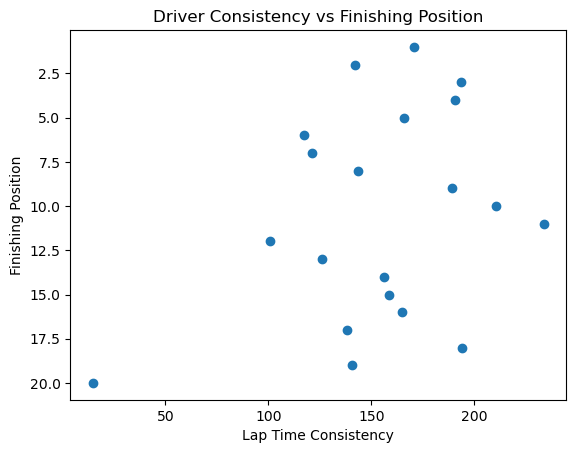

In [105]:
# Analyze lap times by driver
driver_stats = df_laps.groupby("driver_number").agg(
    avg_lap=("lap_duration","mean"),
    best_lap=("lap_duration","min"),
    consistency=("lap_duration","std")
)
new_df = driver_stats.merge(df_results[['driver_number','position']], on='driver_number')
print(new_df.head())
# Plot consistency vs position
plt.scatter(new_df['consistency'], new_df['position'])
plt.xlabel("Lap Time Consistency")
plt.ylabel("Finishing Position")
plt.title("Driver Consistency vs Finishing Position")
plt.gca().invert_yaxis()  # Invert y-axis so 1st place is at the top
plt.show()

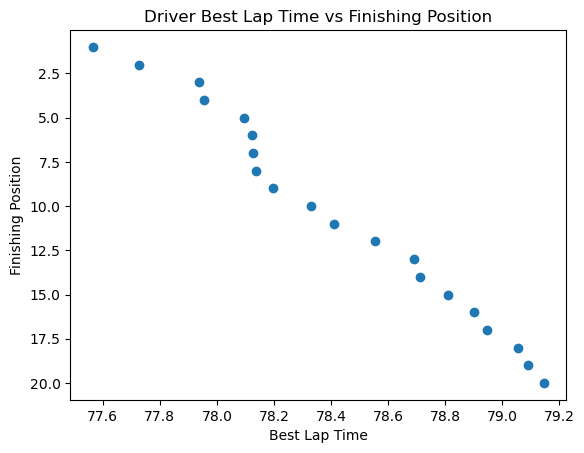

In [106]:
# Best lap vs position
plt.scatter(new_df['best_lap'], new_df['position'])
plt.xlabel("Best Lap Time")
plt.ylabel("Finishing Position")
plt.title("Driver Best Lap Time vs Finishing Position")
plt.gca().invert_yaxis()  # Invert y-axis so 1st place is at the top
plt.show()